        Sector  n  Mass (MeV or eV)
0       lepton  0      5.109754e-04
1       lepton  1      1.064664e-01
2       lepton  2      1.776671e+00
3       lepton  3      1.228173e+03
4       lepton  4      4.363285e+04
5       lepton  5      2.982487e+06
6     up_quark  0      2.409717e-03
7     up_quark  1      1.617104e-01
8     up_quark  2      2.042679e+00
9     up_quark  3      3.029034e+02
10    up_quark  4      6.313596e+03
11    up_quark  5      2.024314e+05
12  down_quark  0      3.740667e-01
13  down_quark  1      1.397659e+00
14  down_quark  2      4.971788e+01
15  down_quark  3      1.353910e+03
16  down_quark  4      5.742855e+03
17  down_quark  5      4.938656e+05
18    neutrino  0      7.943282e-05
19    neutrino  1      2.072556e-03
20    neutrino  2      1.211975e-02
21    neutrino  3      3.162278e-01
22    neutrino  4      8.250996e+00
23    neutrino  5      4.824959e+01


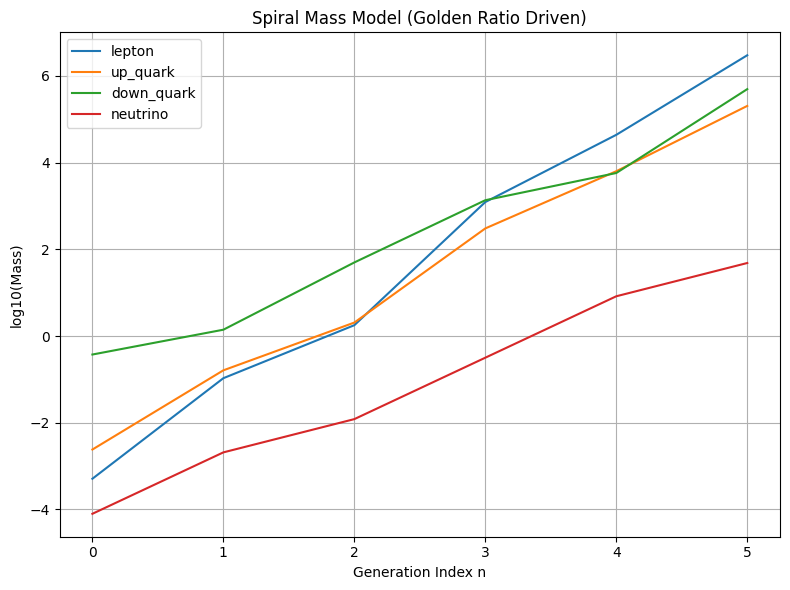

In [2]:
# Golden Spiral Mass Model
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Golden ratio and derived constants
phi = (1 + math.sqrt(5)) / 2
pi = math.pi

# Unified parameter sets
spiral_params = {
    'lepton': {
        'lambda': 2.0033,
        'epsilon': 0.4672,
        'omega': 3.883,
        'phi': pi,
        'log10K': -3.2916
    },
    'up_quark': {
        'lambda': phi,
        'epsilon': 1/(2*phi),
        'omega': 2*pi/phi,
        'phi': pi,
        'log10K': -phi**2
    },
    'down_quark': {
        'lambda': 2/phi,
        'epsilon': 1/(phi**2),
        'omega': 2*pi/phi,
        'phi': pi/2,
        'log10K': -phi/2
    },
    'neutrino': {
        'lambda': 1.2,
        'epsilon': 0.25,
        'omega': 2*pi/3,
        'phi': 0,
        'log10K': -4.1
    }
}

# General mass function
def spiral_mass(n, p):
    theta = p['omega'] * n + p['phi']
    log10m = p['lambda'] * n + p['epsilon'] * math.sin(theta) + p['log10K']
    return 10 ** log10m

# Compute masses for each sector
def compute_masses(sector, n_range):
    p = spiral_params[sector]
    results = []
    for n in n_range:
        mass = spiral_mass(n, p)
        results.append({'Sector': sector, 'n': n, 'Mass (MeV or eV)': mass})
    return pd.DataFrame(results)

# Example: Compute for n = 0 to 5 for all sectors
n_values = range(0, 6)
all_results = pd.concat([
    compute_masses('lepton', n_values),
    compute_masses('up_quark', n_values),
    compute_masses('down_quark', n_values),
    compute_masses('neutrino', n_values)
], ignore_index=True)

# Display results
print(all_results)

# Optional: Plot example spiral
plt.figure(figsize=(8,6))
for sector in ['lepton', 'up_quark', 'down_quark', 'neutrino']:
    df = compute_masses(sector, n_values)
    plt.plot(df['n'], np.log10(df['Mass (MeV or eV)']), label=sector)

plt.xlabel("Generation Index n")
plt.ylabel("log10(Mass)")
plt.title("Spiral Mass Model (Golden Ratio Driven)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
